# PyKoopman: Time Delays

> We use our training data to fit a DMD model by using time embeddings and a single trajectory.

#### Imports

In [1]:
from ast import literal_eval

import matplotlib.pyplot as plt
import numpy as np
import numpy.random as rnd
import pykoopman as pk
from matrepr import mprint
import matrepr
from pydmd import DMD
from safetensors.torch import load_file

from learningdynamics.utils import safetensors_metadata_parser
from learningdynamics.dmd_dataset import reshape_interleave_time

In [2]:
# | hide
np.random.seed(42)  # for reproducibility
%matplotlib inline
matrepr.params.max_cols = 30
matrepr.params.max_rows = 30

#### Load data

The data is stored in 2D [states x length]

each block in the second dimension corresponds to a step for the n_traj

In [3]:
file_path = "../saved_weights/states.safetensors"

metadata = safetensors_metadata_parser(file_path=file_path)
NUM_LOOP_ITERATIONS = literal_eval(metadata["NUM_LOOP_ITERATIONS"])
NUM_TRAJECTORIES = literal_eval(metadata["NUM_TRAJECTORIES"])
NUM_STATES = literal_eval(metadata["NUM_STATES"])

data = load_file(file_path)

#### Update dataset

In [4]:
# train_idx = np.random.choice(NUM_TRAJECTORIES)
train_idx = 3

In [5]:
# test_idx = np.random.choice(NUM_TRAJECTORIES)
test_idx = 0

In [6]:
NUM_TRAJECTORIES = 1
NUM_LOOP_ITERATIONS = 5

NUM_DELAYS = 1
RANK = 5

In [7]:
t = np.arange(0, NUM_LOOP_ITERATIONS, 1)

#### Learn Koopman Operator

Using time delay observables

In [8]:
train_states = reshape_interleave_time(
    data["train_states"][:NUM_LOOP_ITERATIONS, [train_idx], :]
)
test_states = reshape_interleave_time(
    data["test_states"][:NUM_LOOP_ITERATIONS, [test_idx], :]
)
observables = pk.observables.TimeDelay(n_delays=NUM_DELAYS)

In [9]:
regressor = pk.regression.EDMD()
# regressor = DMD(svd_rank=RANK)

# Time shift data
X = train_states[:, :-NUM_TRAJECTORIES].numpy()
Y = train_states[:, NUM_TRAJECTORIES:].numpy()

dmd_model = pk.Koopman(observables=observables, regressor=regressor)
dmd_model.fit(X.T)

Koopman(observables=TimeDelay(n_delays=1), regressor=EDMD())

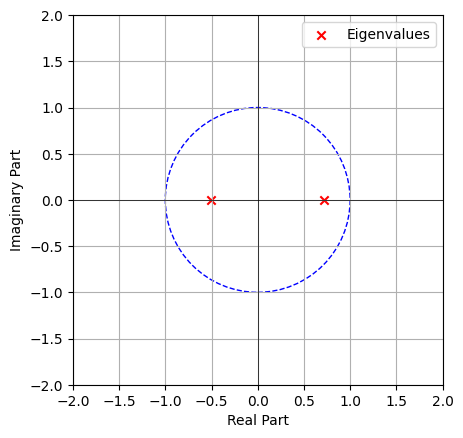

In [10]:
# Assuming koop_eigenvals is already defined
koop_eigenvals = np.linalg.eig(dmd_model.A)[0]

# Create the figure and axis
fig, ax = plt.subplots()

# Plot the unit circle
unit_circle = plt.Circle((0, 0), 1, color="b", fill=False, linestyle="--")
ax.add_artist(unit_circle)

# Plot the eigenvalues
ax.scatter(
    koop_eigenvals.real, koop_eigenvals.imag, color="r", marker="x", label="Eigenvalues"
)

# Set the axis limits
ax.set_xlim([-2, 2])
ax.set_ylim([-2, 2])

# Add grid, legend, and labels
ax.grid(True)
ax.axhline(0, color="black", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Real Part")
ax.set_ylabel("Imaginary Part")
ax.legend()

# Show the plot
plt.show()

/opt/conda/lib/python3.10/site-packages/pykoopman/koopman.py:285: ComplexWarning: Casting complex values to real discards the imaginary part
  y[0] = self.lamda @ self.psi(x0).flatten()
/opt/conda/lib/python3.10/site-packages/pykoopman/koopman.py:290: ComplexWarning: Casting complex values to real discards the imaginary part
  y[k + 1] = self.lamda @ y[k]


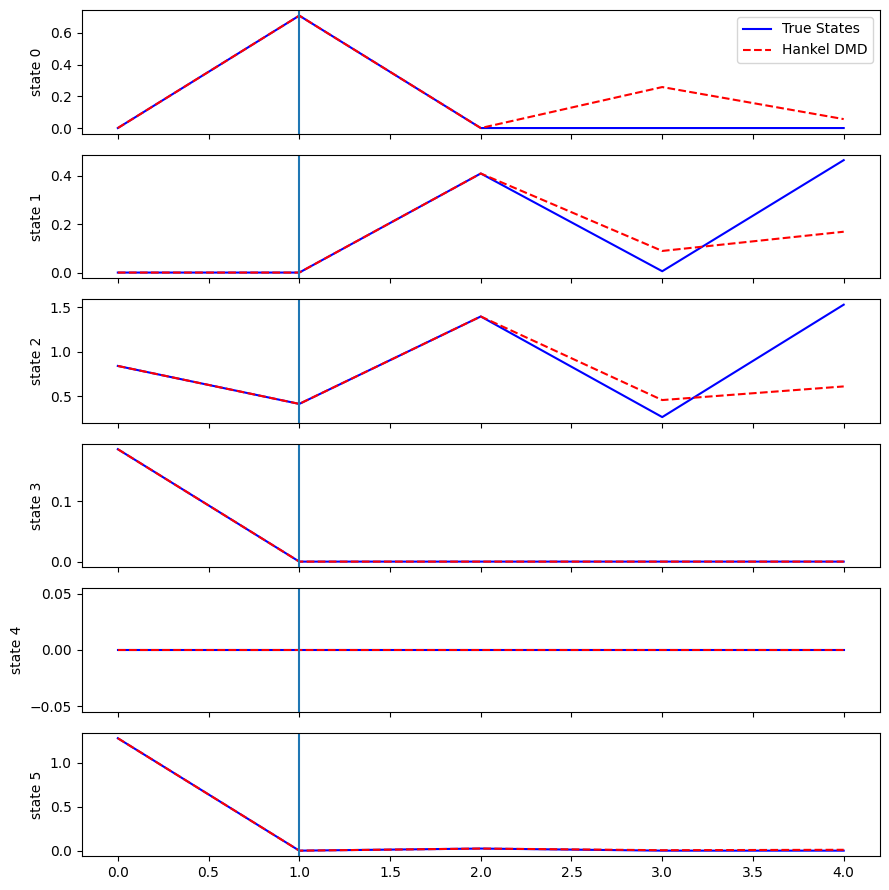

In [11]:
x0_td = train_states[:, : NUM_DELAYS + 1].T.numpy()
Xkoop = dmd_model.simulate(x0_td, n_steps=NUM_LOOP_ITERATIONS - 1 - NUM_DELAYS)
Xkoop = np.vstack([x0_td, Xkoop])

fig, axs = plt.subplots(NUM_STATES, 1, sharex=True, tight_layout=True, figsize=(9, 9))

for state_idx in range(0, NUM_STATES):
    axs[state_idx].plot(
        t, train_states[state_idx, :], "-", color="b", label="True States"
    )
    axs[state_idx].plot(t, Xkoop[:, state_idx], "--r", label="Hankel DMD")
    axs[state_idx].set(ylabel=f"state {state_idx}")

for i in range(0, NUM_STATES):
    axs[i].axvline(x=t[NUM_DELAYS])
axs[0].legend()

/opt/conda/lib/python3.10/site-packages/pykoopman/koopman.py:285: ComplexWarning: Casting complex values to real discards the imaginary part
  y[0] = self.lamda @ self.psi(x0).flatten()
/opt/conda/lib/python3.10/site-packages/pykoopman/koopman.py:290: ComplexWarning: Casting complex values to real discards the imaginary part
  y[k + 1] = self.lamda @ y[k]


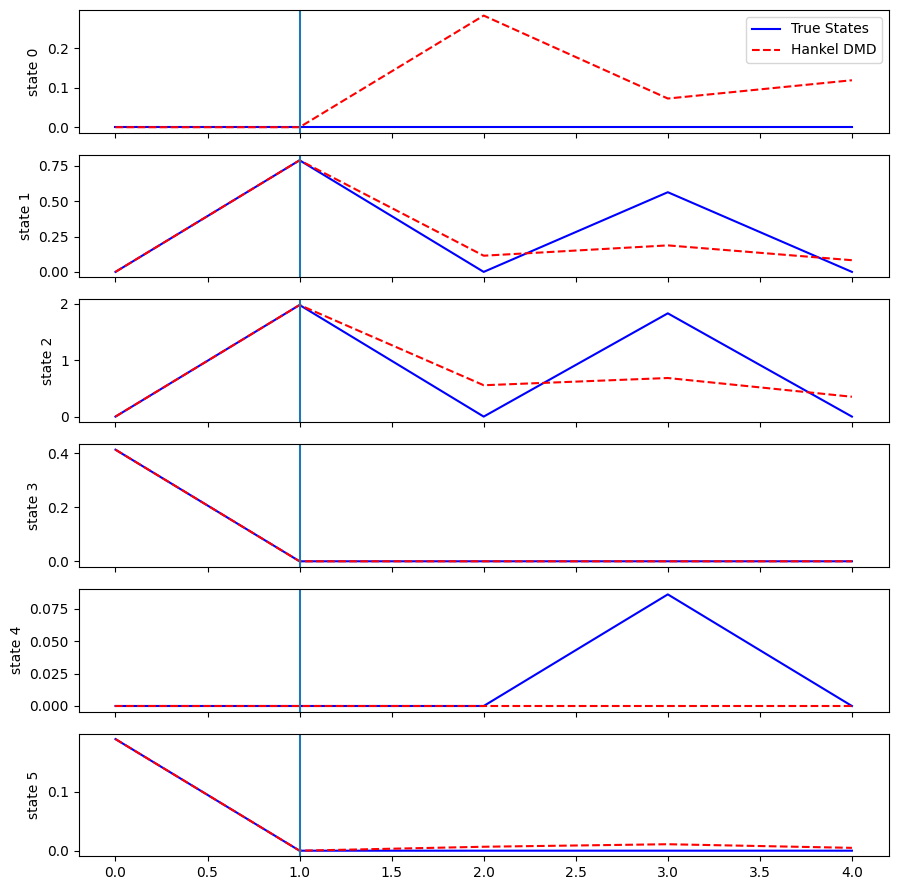

In [12]:
x0_td = test_states[:, : NUM_DELAYS + 1].T.numpy()
Xkoop = dmd_model.simulate(x0_td, n_steps=NUM_LOOP_ITERATIONS - 1 - NUM_DELAYS)
Xkoop = np.vstack([x0_td, Xkoop])

fig, axs = plt.subplots(NUM_STATES, 1, sharex=True, tight_layout=True, figsize=(9, 9))

for state_idx in range(0, NUM_STATES):
    axs[state_idx].plot(
        t, test_states[state_idx, :], "-", color="b", label="True States"
    )
    axs[state_idx].plot(t, Xkoop[:, state_idx], "--r", label="Hankel DMD")
    axs[state_idx].set(ylabel=f"state {state_idx}")

for i in range(0, NUM_STATES):
    axs[i].axvline(x=t[NUM_DELAYS])
axs[0].legend()